<a href="https://colab.research.google.com/github/Fa-Abdullah/Appie-Responsive-Website/blob/main/MHA_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("pashupatigupta/emotion-detection-from-text")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'emotion-detection-from-text' dataset.
Path to dataset files: /kaggle/input/emotion-detection-from-text


In [ ]:
import pandas as pd
import os

print(os.listdir(path))

file_name = 'tweet_emotions.csv'
full_file_path = os.path.join(path, file_name)

df = pd.read_csv(full_file_path)

['tweet_emotions.csv']


In [ ]:
df.head()

,tweet_id,sentiment,content
0,1956967341,empty,@tiffanylue i know i was listenin to bad habi...
1,1956967666,sadness,Layin n bed with a headache ughhhh...waitin o...
2,1956967696,sadness,Funeral ceremony...gloomy friday...
3,1956967789,enthusiasm,wants to hang out with friends SOON!
4,1956968416,neutral,@dannycastillo We want to trade with someone w...


In [ ]:
df.describe()

,tweet_id
count,4.000000e+04
mean,1.845184e+09
std,1.188579e+08
min,1.693956e+09
25%,1.751431e+09
50%,1.855443e+09
75%,1.962781e+09
max,1.966441e+09


In [ ]:
df.isnull().sum()

,0
tweet_id,0
sentiment,0
content,0


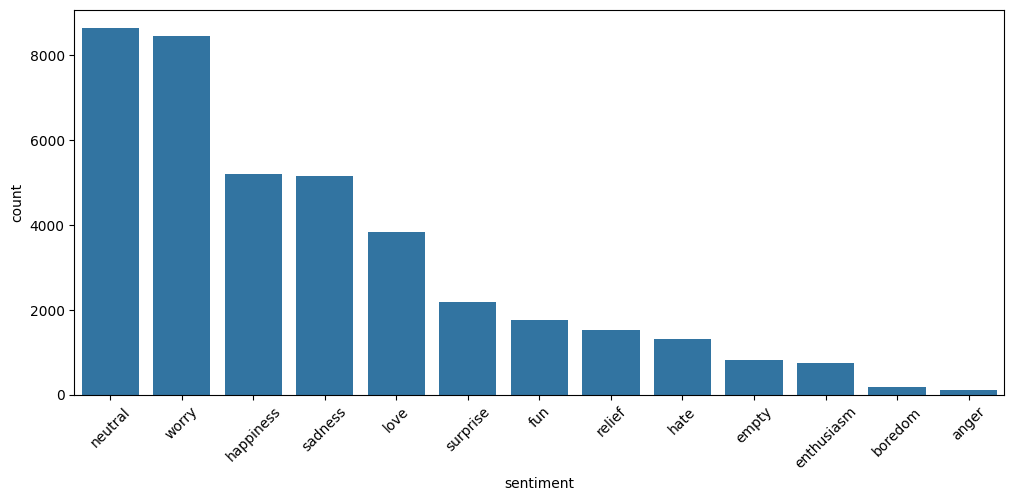

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.countplot(x='sentiment', data=df, order=df['sentiment'].value_counts().index)
plt.xticks(rotation=45)
plt.show()

In [ ]:
from sklearn.utils import resample

balanced_dfs = []
n_samples = 2000

for sentiment in df['sentiment'].unique():
    df_sentiment = df[df['sentiment'] == sentiment]

    df_resampled = resample(df_sentiment, replace=True, random_state=42)

    balanced_dfs.append(df_resampled)

df_balanced = pd.concat(balanced_dfs)

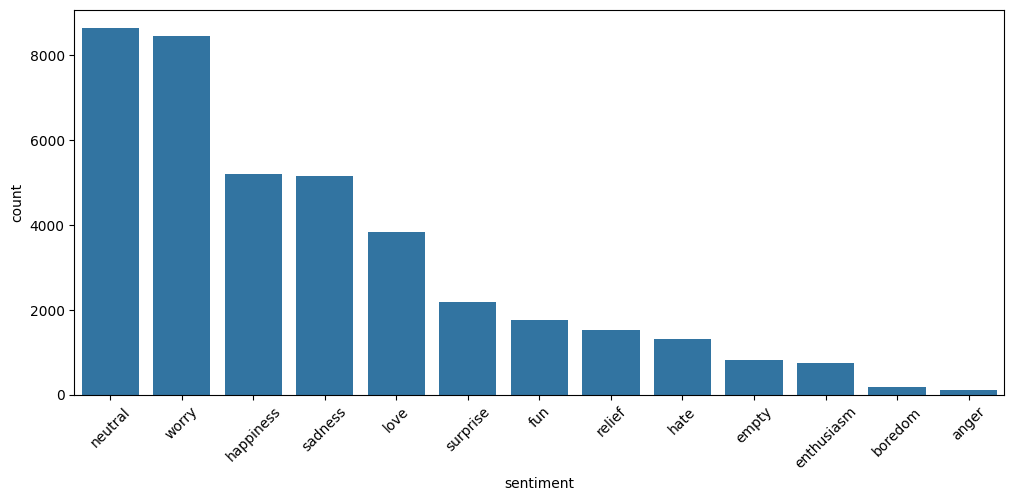

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(x='sentiment', data=df_balanced, order=df_balanced['sentiment'].value_counts().index)
plt.xticks(rotation=45)
plt.show()

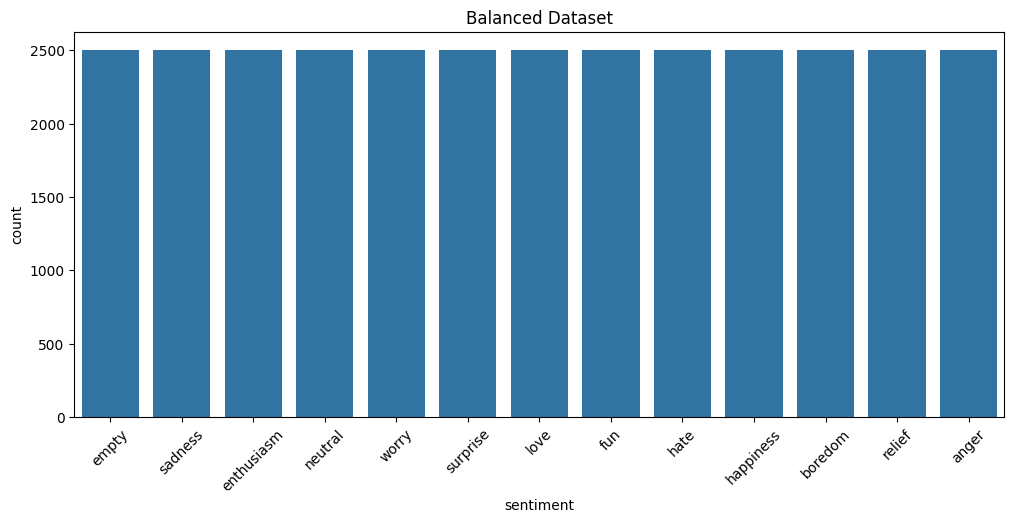

In [ ]:
from sklearn.utils import resample
import pandas as pd

target = 2500
balanced = []

for label in df['sentiment'].unique():
    dfLabel = df[df['sentiment'] == label]
    dfLabel_balanced = resample(dfLabel, replace=True, n_samples=target, random_state=42)
    balanced.append(dfLabel_balanced)

df_balanced = pd.concat(balanced)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,5))
sns.countplot(x='sentiment', data=df_balanced)
plt.xticks(rotation=45)
plt.title("Balanced Dataset")
plt.show()

Average Polarity Score: 0.09827500700006894


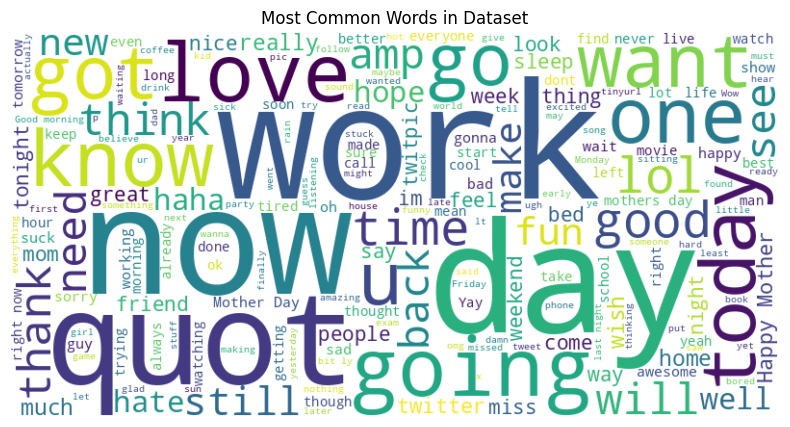

In [ ]:
from wordcloud import WordCloud
from textblob import TextBlob

df_balanced['polarity'] = df_balanced['content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
print("Average Polarity Score:", df_balanced['polarity'].mean())

all_text = " ".join(df_balanced['content'].astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Dataset')
plt.show()

In [ ]:
import string
import re
punct = f"[{re.escape(string.punctuation)}]"
df_balanced['content'] = df_balanced['content'].str.replace(punct, '', regex=True)

In [ ]:
df_balanced.head()

,tweet_id,sentiment,content,polarity
5291,1960718050,empty,I dont want to program today,0.000
18958,1966120973,empty,i got peanut butter in my beard it felt weird...,0.000
13036,1963857563,empty,Fidel has no balls,0.000
5445,1960857150,empty,jenthegingerkd c2s cjewel JenSchaller I like f...,0.125
3493,1958059684,empty,Ugh 2 days whatever to somewhere,0.000


In [ ]:
!pip install nltk

In [ ]:
import nltk

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

texts = df_balanced['content'].values
df_balanced['content'] = [" ".join([w for w in text.split() if w not in stop_words]) for text in texts]

In [ ]:
nltk.download('wordnet')

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

texts = df_balanced['content'].values
df_balanced['content'] = [" ".join([lemmatizer.lemmatize(w) for w in text.split()]) for text in texts]

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
from nltk.tokenize import word_tokenize
import nltk

nltk.download('punkt_tab')
df_balanced['tokens'] = df_balanced['content'].apply(word_tokenize)

tokens = [word for tokens in df_balanced['tokens'] for word in tokens]
vocab = sorted(list(set(tokens)))
word_index = {word: i + 1 for i, word in enumerate(vocab[:10000])}

def sequence_data(tokens):
    return [word_index.get(word, 0) for word in tokens]

df_balanced['sequences'] = df_balanced['tokens'].apply(sequence_data)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

X = pad_sequences(df_balanced['sequences'], maxlen=80, padding='post')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(df_balanced['sentiment'])

print("Shape of X:", X.shape)
print("Classes found:", le.classes_)

Shape of X: (32500, 80)
Classes found: ['anger' 'boredom' 'empty' 'enthusiasm' 'fun' 'happiness' 'hate' 'love'
 'neutral' 'relief' 'sadness' 'surprise' 'worry']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

embedding_dim = 100

class MHA(nn.Module):
    def __init__(self, embedding_dim, heads):
        super(MHA, self).__init__()
        self.embedding_dim = embedding_dim
        self.heads = heads
        self.head_dim = embedding_dim // heads

        assert self.head_dim * heads == embedding_dim, "Embed dim must be divisible by heads"

        self.q_linear = nn.Linear(embedding_dim, embedding_dim)
        self.k_linear = nn.Linear(embedding_dim, embedding_dim)
        self.v_linear = nn.Linear(embedding_dim, embedding_dim)

        self.out_linear = nn.Linear(embedding_dim, embedding_dim)

    def forward(self, x):
        batch_size, sequence_len, embedding_dim = x.size()

        q = self.q_linear(x)
        k = self.k_linear(x)
        v = self.v_linear(x)

        q = q.view(batch_size, sequence_len, self.heads, self.head_dim).transpose(1, 2)
        k = k.view(batch_size, sequence_len, self.heads, self.head_dim).transpose(1, 2)
        v = v.view(batch_size, sequence_len, self.heads, self.head_dim).transpose(1, 2)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        weights = F.softmax(scores, dim=-1)

        attention_out = torch.matmul(weights, v)

        attention_out = attention_out.transpose(1, 2).contiguous().view(batch_size, sequence_len, embedding_dim)

        return self.out_linear(attention_out)

In [ ]:
class Classifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, num_heads, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.attention = MHA(embedding_dim, num_heads)

        self.fc1 = nn.Linear(embedding_dim, 64)
        self.fc2 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = self.attention(x)

        x = torch.mean(x, dim=1)

        x = F.relu(self.fc1(x))
        return self.fc2(x)

In [ ]:
v_size = len(word_index) + 1
out_size = len(le.classes_)

my_model = Classifier(v_size, 128, 8, out_size)
opt = torch.optim.Adam(my_model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

x_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)

batch_size = 64

for epoch in range(30):
    epoch_loss = 0.0
    batch_count = 0

    for i in range(0, len(x_train_tensor), batch_size):

        x_batch = x_train_tensor[i:i+batch_size]
        y_batch = y_train_tensor[i:i+batch_size]
        my_model.train()
        pred = my_model(x_batch)

        loss = loss_fn(pred, y_batch)

        opt.zero_grad()
        loss.backward()
        opt.step()

        epoch_loss += loss.item()
        batch_count += 1

    avg_loss = epoch_loss / batch_count
    print(f'Epoch {epoch+1} | Loss: {avg_loss:.5f}')

Epoch 1 | Loss: 2.46968
Epoch 2 | Loss: 2.21882
Epoch 3 | Loss: 2.04120
Epoch 4 | Loss: 1.88270
Epoch 5 | Loss: 1.73786
Epoch 6 | Loss: 1.61909
Epoch 7 | Loss: 1.52133
Epoch 8 | Loss: 1.43736
Epoch 9 | Loss: 1.37398
Epoch 10 | Loss: 1.32149
Epoch 11 | Loss: 1.27479
Epoch 12 | Loss: 1.24961
Epoch 13 | Loss: 1.21920
Epoch 14 | Loss: 1.20725
Epoch 15 | Loss: 1.18899
Epoch 16 | Loss: 1.17499
Epoch 17 | Loss: 1.16645
Epoch 18 | Loss: 1.15845
Epoch 19 | Loss: 1.15007
Epoch 20 | Loss: 1.14535
Epoch 21 | Loss: 1.13724
Epoch 22 | Loss: 1.14229
Epoch 23 | Loss: 1.13114
Epoch 24 | Loss: 1.12969
Epoch 25 | Loss: 1.12600
Epoch 26 | Loss: 1.12036
Epoch 27 | Loss: 1.11959
Epoch 28 | Loss: 1.11647
Epoch 29 | Loss: 1.11353
Epoch 30 | Loss: 1.11090


In [ ]:
my_model.eval()
with torch.no_grad():
    sample_x = torch.LongTensor(X_test[:10])
    sample_y = y_test[:10]

    outputs = my_model(sample_x)
    _, predicted = torch.max(outputs, 1)

    class_names = le.classes_
    for i in range(len(sample_x)):
        print(f" Predicted: {class_names[predicted[i]]} | Actual: {class_names[sample_y[i]]}")

 Predicted: enthusiasm | Actual: happiness
 Predicted: worry | Actual: happiness
 Predicted: worry | Actual: surprise
 Predicted: empty | Actual: anger
 Predicted: sadness | Actual: sadness
 Predicted: worry | Actual: hate
 Predicted: surprise | Actual: worry
 Predicted: empty | Actual: hate
 Predicted: surprise | Actual: surprise
 Predicted: love | Actual: happiness


In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

my_model.eval()
preds = []
labels = []

with torch.no_grad():
    outputs = my_model(torch.LongTensor(X_test))
    _, predicted = torch.max(outputs, 1)
    preds.extend(predicted.numpy())
    labels.extend(y_test)


In [ ]:
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.87      0.67      0.75       771
           1       0.88      0.61      0.72       777
           2       0.19      0.81      0.31       729
           3       0.70      0.59      0.64       730
           4       0.72      0.39      0.51       776
           5       0.37      0.27      0.31       735
           6       0.60      0.42      0.50       727
           7       0.52      0.32      0.39       720
           8       0.33      0.16      0.22       777
           9       0.48      0.43      0.45       718
          10       0.39      0.24      0.30       767
          11       0.55      0.36      0.43       760
          12       0.23      0.29      0.25       763

    accuracy                           0.43      9750
   macro avg       0.52      0.43      0.45      9750
weighted avg       0.53      0.43      0.45      9750



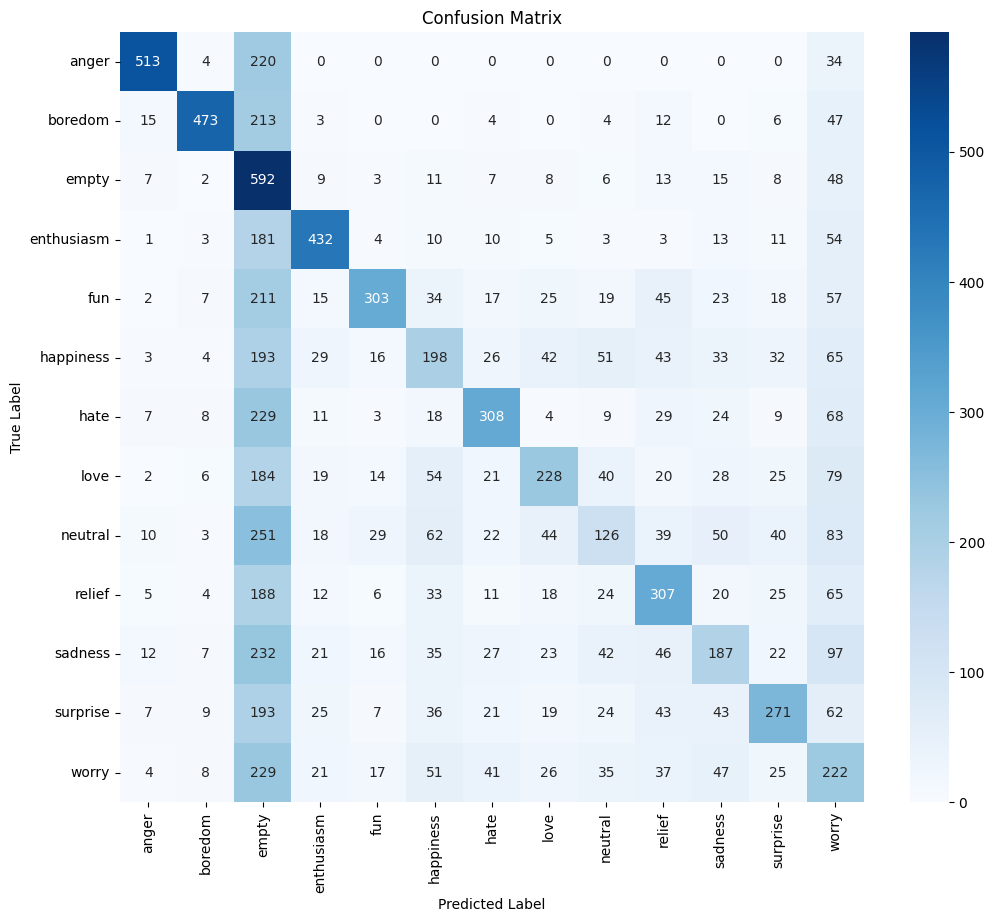

In [ ]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 1- Why is unifying sequences length required ?
--->>>(A) To have equal lengths along all samples.

(B) To enhance the model performance.

(C) To obtain contextual information correctly.

(D) All of the mentioned.

2- The architecture designed for this task is similar to which part of transformer architecture ?
(A) Decoder

--->>>(B) Encoder

(C) Positional Encoding

(D) None of the Mentioned

3- What is the benefit of adding Self-Attention Mechanism to the architecture for classifying the emotion of the text ?
(A) Detect the abnormal behavior along the text.

(B) Learn the underlying features along dimensions.

--->>>(C) Adding the contextual information and relative tokens.

(D) A & C